# Kinematic Margin — Empirical CDF

Empirical CDF of the kinematic margin per buffer segment. Margin `M < 0` means the buffer window is too tight to correct kinematically, so the curve's value at `m = 0` is exactly that segment's failure rate `P(M < 0)` — readable directly off the plot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

import sys
sys.path.insert(0, '..')

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.visualization.segment_event_plots import plot_margin_cdf

## Run simulation

In [2]:
config_path = Path("../configs/system/default.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)

print(f"Config: batch={cfg['batch']}, n_buffer_seg={cfg['n_buffer_seg']}")
print(f"Solver: {cfg.get('solver', 'scurve')}")

sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

margin = result.segment_sync_response.kinematic_margin
n_segments = cfg['n_buffer_seg']

print(f"margin shape: {margin.shape}")

Config: batch=100, n_buffer_seg=7
Solver: ruckig
margin shape: (99, 7)


## Margin CDF — first segments

`plot_margin_cdf` plots the empirical CDF of the margin for each segment as a step curve, with a dashed vertical line at the `M = 0` failure boundary. The annotated value where each curve crosses `m = 0` is that segment's failure rate `P(M < 0)`.

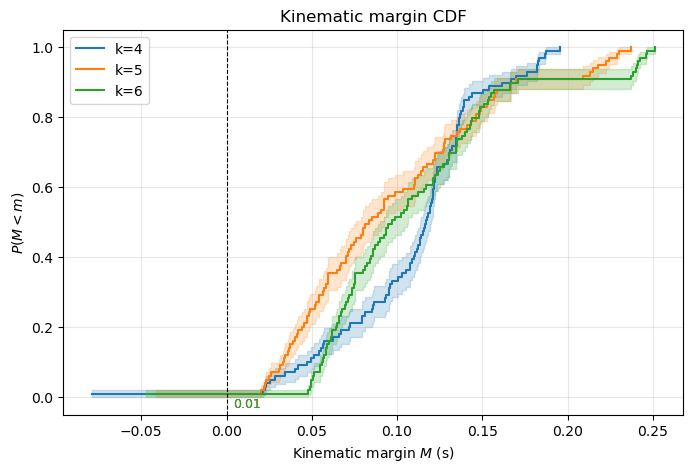

In [3]:
fig, ax = plot_margin_cdf(
    margin,
    segments = range(4, n_segments),
    title=f"Kinematic margin CDF",
)
ax.grid(alpha=0.3)
plt.show()

## Margin CDF — last segments

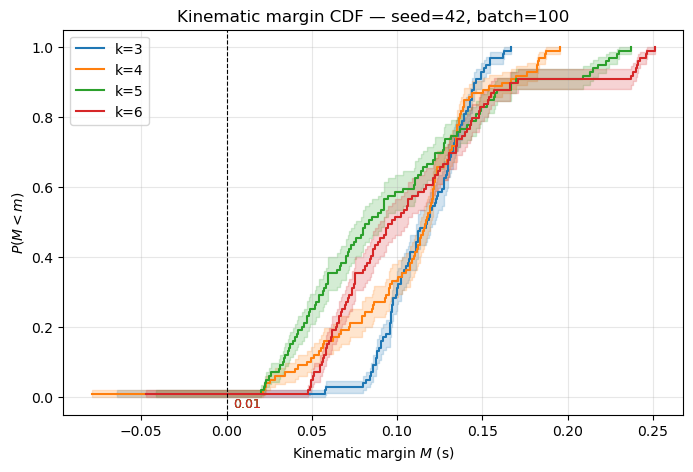

In [4]:
fig, ax = plot_margin_cdf(
    margin,
    segments=range(max(0, n_segments - 4), n_segments),
    title=f"Kinematic margin CDF — seed=42, batch={cfg['batch']}",
)
ax.grid(alpha=0.3)
plt.show()

In [5]:
margin.shape

(99, 7)